In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
files_map = {
    "group1": "google_trends_group1.csv",
    "group2": "google_trends_group2.csv",
    "group3": "google_trends_group3.csv",
    "group4": "google_trends_group4.csv",
    "group5": "google_trends_group5.csv",
    "group6": "google_trends_group6.csv",
}

anchor_col = "Indian Institute Of Technology Delhi (IIT Delhi)"
anchor_name = "IIT Delhi"

rename_map = {
    "Indian Institute Of Technology Delhi (IIT Delhi)": "IIT Delhi",
    "Indian Institute of Technology Kanpur": "IIT Kanpur",
    "Indian Institute of Technology, Kharagpur": "IIT Kharagpur",
    "Indian Institute Of Technology–Madras (IIT–Madras)": "IIT Madras",
    "Indian Institute of Technology Bombay": "IIT Bombay",

    "Indian Institute of Technology Guwahati": "IIT Guwahati",
    "Indian Institute Of Technology Roorkee": "IIT Roorkee",
    "Indian Institute Of Technology–Ropar (IIT–Ropar)": "IIT Ropar",
    "Indian Institute of Technology, Patna": "IIT Patna",

    "Indian Institute Of Technology Gandhinagar (IIT Gandhinagar)": "IIT Gandhinagar",
    "Indian Institute of Technology, Hyderabad": "IIT Hyderabad",
    "Indian Institute of Technology (IIT), Jodhpur": "IIT Jodhpur",
    "Indian Institute Of Technology (IIT) Bhubaneswar": "IIT Bhubaneswar",

    "Indian Institute of Technology Indore": "IIT Indore",
    "Indian Institute of Technology Mandi": "IIT Mandi",
    "Indian Institute of Technology (BHU) Varanasi": "IIT BHU",
    "Indian Institute Of Technology–Palakkad (IIT–Palakkad)": "IIT Palakkad",

    "Indian Institute Of Technology (IIT) Tirupati": "IIT Tirupati",
    "Indian Institute of Technology (Indian School of Mines), Dhanbad": "IIT Dhanbad",
    "Indian Institute of Technology Bhilai": "IIT Bhilai",
    "Indian Institute Of Technology Goa": "IIT Goa",

    "Indian Institute of Technology, Jammu": "IIT Jammu",
    "Indian Institute Of Technology Dharwad": "IIT Dharwad",
}

iit_order = [
    "IIT Kharagpur", "IIT Bombay", "IIT Madras", "IIT Kanpur", "IIT Delhi",
    "IIT Guwahati", "IIT Roorkee", "IIT Ropar", "IIT Bhubaneswar",
    "IIT Gandhinagar", "IIT Hyderabad", "IIT Jodhpur", "IIT Patna",
    "IIT Indore", "IIT Mandi", "IIT BHU", "IIT Palakkad", "IIT Tirupati",
    "IIT Dhanbad", "IIT Bhilai", "IIT Goa", "IIT Jammu", "IIT Dharwad"
]

In [3]:
group_dfs = {}

for group, filename in files_map.items():
    df = pd.read_csv(filename)
    df["Time"] = pd.to_datetime(df["Time"])
    df = df.set_index("Time")
    df = df.rename(columns=rename_map)

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    group_dfs[group] = df

# Use group1 Delhi series as master anchor
master = group_dfs["group1"].copy()
master_anchor = master[anchor_name]

merged = master.copy()

for group_name, df in group_dfs.items():
    if group_name == "group1":
        continue

    common_dates = master_anchor.index.intersection(df.index)

    anchor_master = master_anchor.loc[common_dates]
    anchor_group = df.loc[common_dates, anchor_name]

    valid = (anchor_master > 0) & (anchor_group > 0)

    if valid.sum() > 0:
        scale_factor = (anchor_master[valid] / anchor_group[valid]).median()
    else:
        scale_factor = 1

    print(group_name, "scale factor:", scale_factor)

    scaled_df = df * scale_factor

    for col in scaled_df.columns:
        if col == anchor_name:
            continue
        merged[col] = scaled_df[col]

# Keep all IITs in desired order
trends_monthly = merged[iit_order]

trends_monthly.to_csv("iit_google_trends_monthly_normalized.csv")

trends_monthly.head()

group2 scale factor: 0.6379895158803577
group3 scale factor: 0.6379895158803577
group4 scale factor: 0.6379895158803577
group5 scale factor: 0.6379895158803577
group6 scale factor: 0.6379895158803577


,IIT Kharagpur,IIT Bombay,IIT Madras,IIT Kanpur,IIT Delhi,IIT Guwahati,IIT Roorkee,IIT Ropar,IIT Bhubaneswar,IIT Gandhinagar,...,IIT Indore,IIT Mandi,IIT BHU,IIT Palakkad,IIT Tirupati,IIT Dhanbad,IIT Bhilai,IIT Goa,IIT Jammu,IIT Dharwad
Time,,,,,,,,,,,,,,,,,,,,,
2021-07-01,37,41,38,23,47,0.0,17.863706,3.827937,4.465927,4.465927,...,4.465927,3.827937,9.569843,2.551958,3.189948,10.207832,1.913969,1.913969,1.913969,1.913969
2021-08-01,35,40,37,23,46,0.0,18.501696,3.189948,3.189948,5.741906,...,3.827937,4.465927,7.655874,2.551958,2.551958,9.569843,2.551958,1.913969,1.913969,1.275979
2021-09-01,41,44,35,23,52,0.0,19.139685,3.827937,3.189948,5.741906,...,3.827937,3.827937,7.655874,2.551958,1.913969,8.293864,1.913969,3.189948,1.913969,1.275979
2021-10-01,34,44,32,29,56,0.0,20.415665,5.103916,5.103916,5.741906,...,6.379895,5.741906,11.483811,3.827937,3.189948,10.207832,2.551958,3.189948,3.189948,2.551958
2021-11-01,36,42,30,29,48,0.0,21.691644,3.827937,5.741906,5.103916,...,5.103916,5.741906,12.121801,3.189948,3.189948,9.569843,1.913969,1.913969,3.189948,2.551958


In [4]:
avg_interest = (
    trends_monthly
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

avg_interest.columns = ["iit", "average_google_trends_interest"]

avg_interest.to_csv("iit_google_trends_average_interest.csv", index=False)

avg_interest

,iit,average_google_trends_interest
0,IIT Madras,60.850000
1,IIT Bombay,58.000000
2,IIT Delhi,51.466667
3,IIT Kharagpur,42.383333
4,IIT Kanpur,36.200000
5,IIT Roorkee,17.374581
6,IIT BHU,15.269216
7,IIT Hyderabad,14.737558
8,IIT Dhanbad,11.622042
9,IIT Mandi,10.101501


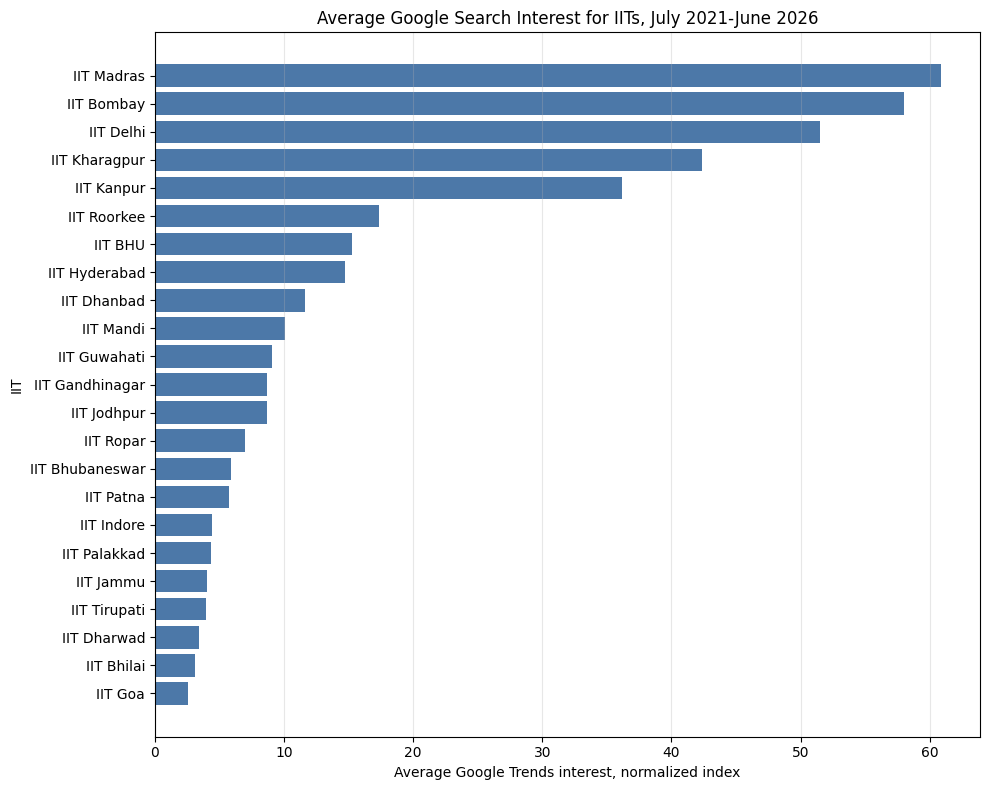

In [5]:
plot_df = avg_interest.sort_values("average_google_trends_interest", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(
    plot_df["iit"],
    plot_df["average_google_trends_interest"],
    color="#4C78A8"
)

plt.xlabel("Average Google Trends interest, normalized index")
plt.ylabel("IIT")
plt.title("Average Google Search Interest for IITs, July 2021-June 2026")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig("iit_google_trends_average_interest.png", dpi=300)
plt.show()

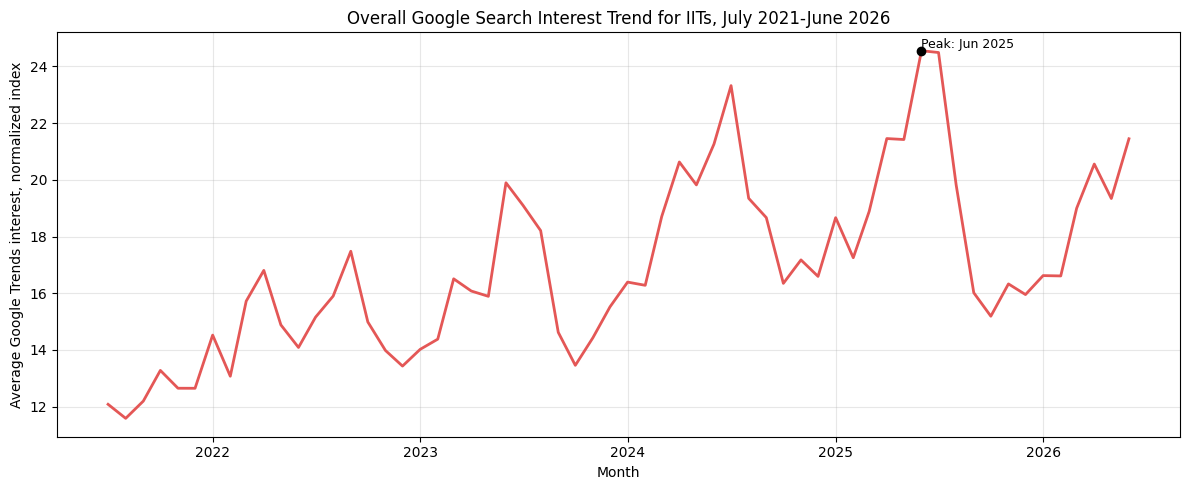

Overall peak month: June 2025


In [6]:
overall_monthly = trends_monthly.mean(axis=1)

peak_date = overall_monthly.idxmax()
peak_value = overall_monthly.max()

plt.figure(figsize=(12, 5))
plt.plot(
    overall_monthly.index,
    overall_monthly,
    color="#E45756",
    linewidth=2
)

plt.scatter(peak_date, peak_value, color="black", zorder=5)

plt.text(
    peak_date,
    peak_value,
    f"Peak: {peak_date.strftime('%b %Y')}",
    fontsize=9,
    ha="left",
    va="bottom"
)

plt.xlabel("Month")
plt.ylabel("Average Google Trends interest, normalized index")
plt.title("Overall Google Search Interest Trend for IITs, July 2021-June 2026")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("iit_google_trends_overall_monthly_trend.png", dpi=300)
plt.show()

print("Overall peak month:", peak_date.strftime("%B %Y"))

In [7]:
peak_rows = []

for term in iit_order:
    peak_date = trends_monthly[term].idxmax()
    peak_value = trends_monthly[term].max()

    peak_rows.append({
        "iit": term,
        "peak_month": peak_date.strftime("%B %Y"),
        "peak_value": peak_value
    })

peak_df = pd.DataFrame(peak_rows)
peak_df = peak_df.sort_values("peak_value", ascending=False)

peak_df.to_csv("iit_google_trends_peak_months.csv", index=False)

peak_df

,iit,peak_month,peak_value
2,IIT Madras,May 2025,100.000000
1,IIT Bombay,April 2024,82.000000
0,IIT Kharagpur,January 2022,70.000000
4,IIT Delhi,June 2025,64.000000
3,IIT Kanpur,March 2023,51.000000
5,IIT Guwahati,July 2025,33.813444
6,IIT Roorkee,August 2025,32.537465
10,IIT Hyderabad,June 2025,24.881591
15,IIT BHU,November 2023,24.881591
14,IIT Mandi,June 2025,18.501696


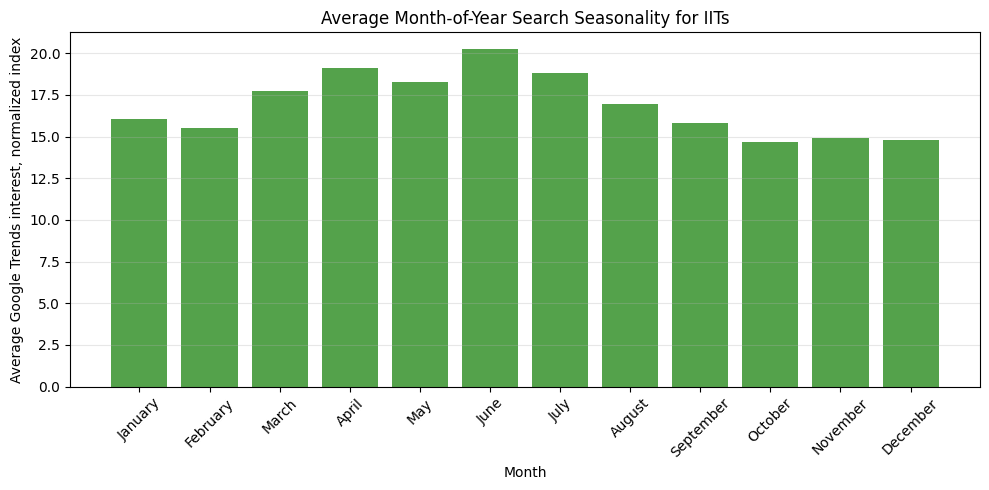

Most common seasonal peak month: June


In [8]:
seasonality_source = trends_monthly.copy()
seasonality_source["month"] = seasonality_source.index.month_name()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

seasonality = (
    seasonality_source
    .groupby("month")[iit_order]
    .mean()
    .mean(axis=1)
    .reindex(month_order)
)

seasonality_df = seasonality.reset_index()
seasonality_df.columns = ["month", "average_google_trends_interest"]

seasonality_df.to_csv("iit_google_trends_monthly_seasonality.csv", index=False)

plt.figure(figsize=(10, 5))
plt.bar(
    seasonality_df["month"],
    seasonality_df["average_google_trends_interest"],
    color="#54A24B"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Average Google Trends interest, normalized index")
plt.title("Average Month-of-Year Search Seasonality for IITs")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("iit_google_trends_monthly_seasonality.png", dpi=300)
plt.show()

peak_seasonal_month = seasonality_df.loc[
    seasonality_df["average_google_trends_interest"].idxmax(),
    "month"
]

print("Most common seasonal peak month:", peak_seasonal_month)